# Notebook 02 — Structured Panel and Risk Score Demo

## Project 01 — RAG Document Intelligence

This notebook demonstrates the structured data pipeline for the Brazil Agro-Environmental AI Portfolio.

The goal is to build a **municipality-year environmental panel** using simplified MapBiomas and INPE / PRODES indicators, then calculate an explainable environmental screening score.

The pipeline is:

```text
MapBiomas municipality-year table
+ INPE / PRODES municipality-year table
→ unified environmental panel
→ native vegetation loss
→ agriculture/pasture expansion
→ normalized indicators
→ environmental risk score
→ environmental risk class
```

This notebook is intentionally simple and robust. It creates synthetic sample data so the pipeline can be tested before real MapBiomas and INPE tables are added.


## 1. Setup

Run this notebook from either:

```text
01-rag-document-intelligence/
```

or:

```text
01-rag-document-intelligence/notebooks/
```

The cell below makes `src/` importable.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()

# If running from notebooks/, move back to the repository root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)


Project root: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence
Source directory: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\src


## 2. Check project directories

This uses the project path utilities.


In [2]:
from agro_rag.utils.paths import (
    ensure_project_directories,
    CLEANED_MAPBIOMAS_DIR,
    CLEANED_INPE_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
)

ensure_project_directories()

print("Cleaned MapBiomas directory:", CLEANED_MAPBIOMAS_DIR)
print("Cleaned INPE directory:", CLEANED_INPE_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Figures directory:", FIGURES_DIR)


Cleaned MapBiomas directory: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_mapbiomas
Cleaned INPE directory: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_inpe
Processed data directory: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\processed
Figures directory: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\reports\figures


## 3. Create synthetic MapBiomas municipality-year data

Expected MapBiomas columns:

```text
municipality_code
municipality_name
state
biome
year
mapbiomas_forest_area_ha
mapbiomas_native_vegetation_area_ha
mapbiomas_agriculture_area_ha
mapbiomas_pasture_area_ha
```

In the real project, this table should come from cleaned MapBiomas statistics.


In [3]:
def build_synthetic_mapbiomas_table() -> pd.DataFrame:
    municipalities = [
        {
            "municipality_code": "5103403",
            "municipality_name": "Cuiabá",
            "state": "MT",
            "biome": "Cerrado",
            "native_base": 180000,
            "agriculture_base": 45000,
            "pasture_base": 60000,
            "pressure": 0.015,
        },
        {
            "municipality_code": "5107909",
            "municipality_name": "Sinop",
            "state": "MT",
            "biome": "Amazon",
            "native_base": 320000,
            "agriculture_base": 90000,
            "pasture_base": 110000,
            "pressure": 0.025,
        },
        {
            "municipality_code": "1501402",
            "municipality_name": "Belém",
            "state": "PA",
            "biome": "Amazon",
            "native_base": 90000,
            "agriculture_base": 10000,
            "pasture_base": 25000,
            "pressure": 0.006,
        },
        {
            "municipality_code": "1505536",
            "municipality_name": "Parauapebas",
            "state": "PA",
            "biome": "Amazon",
            "native_base": 260000,
            "agriculture_base": 25000,
            "pasture_base": 85000,
            "pressure": 0.020,
        },
    ]

    years = list(range(2018, 2025))
    rows = []

    for municipality in municipalities:
        for i, year in enumerate(years):
            native_loss_factor = 1 - municipality["pressure"] * i
            native_area = municipality["native_base"] * native_loss_factor

            agriculture_area = municipality["agriculture_base"] * (1 + 0.020 * i)
            pasture_area = municipality["pasture_base"] * (1 + 0.015 * i)

            forest_area = native_area * 0.75

            rows.append(
                {
                    "municipality_code": municipality["municipality_code"],
                    "municipality_name": municipality["municipality_name"],
                    "state": municipality["state"],
                    "biome": municipality["biome"],
                    "year": year,
                    "mapbiomas_forest_area_ha": round(forest_area, 2),
                    "mapbiomas_native_vegetation_area_ha": round(native_area, 2),
                    "mapbiomas_agriculture_area_ha": round(agriculture_area, 2),
                    "mapbiomas_pasture_area_ha": round(pasture_area, 2),
                }
            )

    return pd.DataFrame(rows)


mapbiomas_df = build_synthetic_mapbiomas_table()

mapbiomas_path = CLEANED_MAPBIOMAS_DIR / "mapbiomas_municipality_year.parquet"
mapbiomas_df.to_parquet(mapbiomas_path, index=False)

print("MapBiomas rows:", len(mapbiomas_df))
print("Saved to:", mapbiomas_path)

mapbiomas_df.head()


MapBiomas rows: 28
Saved to: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_mapbiomas\mapbiomas_municipality_year.parquet


,municipality_code,municipality_name,state,biome,year,mapbiomas_forest_area_ha,mapbiomas_native_vegetation_area_ha,mapbiomas_agriculture_area_ha,mapbiomas_pasture_area_ha
0,5103403,Cuiabá,MT,Cerrado,2018,135000.0,180000.0,45000.0,60000.0
1,5103403,Cuiabá,MT,Cerrado,2019,132975.0,177300.0,45900.0,60900.0
2,5103403,Cuiabá,MT,Cerrado,2020,130950.0,174600.0,46800.0,61800.0
3,5103403,Cuiabá,MT,Cerrado,2021,128925.0,171900.0,47700.0,62700.0
4,5103403,Cuiabá,MT,Cerrado,2022,126900.0,169200.0,48600.0,63600.0


## 4. Create synthetic INPE / PRODES municipality-year data

Expected INPE columns:

```text
municipality_code
year
inpe_prodes_deforestation_area_ha
```

In the real project, this table should come from cleaned INPE / TerraBrasilis / PRODES data.


In [4]:
def build_synthetic_inpe_table() -> pd.DataFrame:
    rows = []

    base_deforestation = {
        "5103403": 450,
        "5107909": 1800,
        "1501402": 120,
        "1505536": 1100,
    }

    trend = {
        "5103403": 35,
        "5107909": 120,
        "1501402": 10,
        "1505536": 90,
    }

    for municipality_code, base_value in base_deforestation.items():
        for i, year in enumerate(range(2018, 2025)):
            deforestation_area = base_value + trend[municipality_code] * i

            rows.append(
                {
                    "municipality_code": municipality_code,
                    "year": year,
                    "inpe_prodes_deforestation_area_ha": round(deforestation_area, 2),
                }
            )

    return pd.DataFrame(rows)


inpe_df = build_synthetic_inpe_table()

inpe_path = CLEANED_INPE_DIR / "inpe_prodes_municipality_year.parquet"
inpe_df.to_parquet(inpe_path, index=False)

print("INPE rows:", len(inpe_df))
print("Saved to:", inpe_path)

inpe_df.head()


INPE rows: 28
Saved to: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_inpe\inpe_prodes_municipality_year.parquet


,municipality_code,year,inpe_prodes_deforestation_area_ha
0,5103403,2018,450
1,5103403,2019,485
2,5103403,2020,520
3,5103403,2021,555
4,5103403,2022,590


## 5. Build the unified environmental panel

This step merges MapBiomas and INPE tables using:

```text
municipality_code + year
```

Output:

```text
data/processed/municipality_environmental_panel.parquet
```


In [5]:
from agro_rag.structured.build_environmental_panel import build_environmental_panel_file

environmental_panel_path = PROCESSED_DATA_DIR / "municipality_environmental_panel.parquet"

panel_df = build_environmental_panel_file(
    mapbiomas_path=mapbiomas_path,
    inpe_path=inpe_path,
    output_path=environmental_panel_path,
    how="left",
)

print("Environmental panel rows:", len(panel_df))
print("Saved to:", environmental_panel_path)

panel_df.head()


Environmental panel rows: 28
Saved to: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\processed\municipality_environmental_panel.parquet


,municipality_code,municipality_name,state,biome,year,mapbiomas_forest_area_ha,mapbiomas_native_vegetation_area_ha,mapbiomas_agriculture_area_ha,mapbiomas_pasture_area_ha,inpe_prodes_deforestation_area_ha
0,5103403,Cuiabá,MT,Cerrado,2018,135000.0,180000.0,45000.0,60000.0,450
1,5103403,Cuiabá,MT,Cerrado,2019,132975.0,177300.0,45900.0,60900.0,485
2,5103403,Cuiabá,MT,Cerrado,2020,130950.0,174600.0,46800.0,61800.0,520
3,5103403,Cuiabá,MT,Cerrado,2021,128925.0,171900.0,47700.0,62700.0,555
4,5103403,Cuiabá,MT,Cerrado,2022,126900.0,169200.0,48600.0,63600.0,590


## 6. Basic panel validation

We check:

- number of rows;
- missing values;
- year range;
- municipalities included.


In [6]:
print("Shape:", panel_df.shape)
print("Years:", panel_df["year"].min(), "to", panel_df["year"].max())
print("Municipalities:", panel_df["municipality_name"].nunique())

missing_summary = panel_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Shape: (28, 10)
Years: 2018 to 2024
Municipalities: 4


Series([], dtype: int64)

In [7]:
panel_df.groupby(["state", "municipality_name"]).agg(
    first_year=("year", "min"),
    last_year=("year", "max"),
    n_years=("year", "nunique"),
    mean_deforestation_ha=("inpe_prodes_deforestation_area_ha", "mean"),
    mean_native_vegetation_ha=("mapbiomas_native_vegetation_area_ha", "mean"),
).reset_index()


,state,municipality_name,first_year,last_year,n_years,mean_deforestation_ha,mean_native_vegetation_ha
0,MT,Cuiabá,2018,2024,7,555.0,171900.0
1,MT,Sinop,2018,2024,7,2160.0,296000.0
2,PA,Belém,2018,2024,7,150.0,88380.0
3,PA,Parauapebas,2018,2024,7,1370.0,244400.0


## 7. Calculate environmental risk score

The risk score uses the module:

```text
src/agro_rag/structured/risk_score.py
```

Default formula:

```text
environmental_risk_score =
    0.50 * normalized_inpe_prodes_deforestation_area_ha
  + 0.30 * normalized_mapbiomas_native_vegetation_loss_ha
  + 0.20 * normalized_mapbiomas_agriculture_or_pasture_expansion_ha
```

Important interpretation:

> This is only an environmental screening indicator. It is not proof of illegal deforestation or legal non-compliance.


In [8]:
from agro_rag.structured.risk_score import score_environmental_panel_file

scored_panel_path = PROCESSED_DATA_DIR / "municipality_environmental_panel_scored.parquet"

scored_df = score_environmental_panel_file(
    input_path=environmental_panel_path,
    output_path=scored_panel_path,
    group_columns=["municipality_code"],
    year_column="year",
)

print("Scored panel rows:", len(scored_df))
print("Saved to:", scored_panel_path)

scored_df.head()


Scored panel rows: 28
Saved to: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\processed\municipality_environmental_panel_scored.parquet


,municipality_code,municipality_name,state,biome,year,mapbiomas_forest_area_ha,mapbiomas_native_vegetation_area_ha,mapbiomas_agriculture_area_ha,mapbiomas_pasture_area_ha,inpe_prodes_deforestation_area_ha,mapbiomas_native_vegetation_loss_ha,mapbiomas_agriculture_or_pasture_expansion_ha,inpe_prodes_deforestation_area_ha_normalized,mapbiomas_native_vegetation_loss_ha_normalized,mapbiomas_agriculture_or_pasture_expansion_ha_normalized,environmental_risk_score,environmental_risk_class
0,1501402,Belém,PA,Amazon,2018,67500.0,90000.0,10000.0,25000.0,120,0.0,0.0,0.000000,0.0000,0.000000,0.000000,Low
1,1501402,Belém,PA,Amazon,2019,67095.0,89460.0,10200.0,25375.0,130,540.0,575.0,0.004167,0.0675,0.166667,0.055667,Low
2,1501402,Belém,PA,Amazon,2020,66690.0,88920.0,10400.0,25750.0,140,540.0,575.0,0.008333,0.0675,0.166667,0.057750,Low
3,1501402,Belém,PA,Amazon,2021,66285.0,88380.0,10600.0,26125.0,150,540.0,575.0,0.012500,0.0675,0.166667,0.059833,Low
4,1501402,Belém,PA,Amazon,2022,65880.0,87840.0,10800.0,26500.0,160,540.0,575.0,0.016667,0.0675,0.166667,0.061917,Low


## 8. Inspect generated score columns

The scoring pipeline creates:

```text
mapbiomas_native_vegetation_loss_ha
mapbiomas_agriculture_or_pasture_expansion_ha
inpe_prodes_deforestation_area_ha_normalized
mapbiomas_native_vegetation_loss_ha_normalized
mapbiomas_agriculture_or_pasture_expansion_ha_normalized
environmental_risk_score
environmental_risk_class
```


In [9]:
score_columns = [
    "municipality_name",
    "state",
    "biome",
    "year",
    "inpe_prodes_deforestation_area_ha",
    "mapbiomas_native_vegetation_loss_ha",
    "mapbiomas_agriculture_or_pasture_expansion_ha",
    "environmental_risk_score",
    "environmental_risk_class",
]

scored_df[score_columns].head(12)


,municipality_name,state,biome,year,inpe_prodes_deforestation_area_ha,mapbiomas_native_vegetation_loss_ha,mapbiomas_agriculture_or_pasture_expansion_ha,environmental_risk_score,environmental_risk_class
0,Belém,PA,Amazon,2018,120,0.0,0.0,0.000000,Low
1,Belém,PA,Amazon,2019,130,540.0,575.0,0.055667,Low
2,Belém,PA,Amazon,2020,140,540.0,575.0,0.057750,Low
3,Belém,PA,Amazon,2021,150,540.0,575.0,0.059833,Low
4,Belém,PA,Amazon,2022,160,540.0,575.0,0.061917,Low
5,Belém,PA,Amazon,2023,170,540.0,575.0,0.064000,Low
6,Belém,PA,Amazon,2024,180,540.0,575.0,0.066083,Low
7,Parauapebas,PA,Amazon,2018,1100,0.0,0.0,0.204167,Low
8,Parauapebas,PA,Amazon,2019,1190,5200.0,1775.0,0.520815,Medium
9,Parauapebas,PA,Amazon,2020,1280,5200.0,1775.0,0.539565,Medium


## 9. Rank municipality-year records by environmental screening score

This shows which municipality-year records deserve more attention according to the synthetic indicators.


In [10]:
top_risk_records = (
    scored_df[score_columns]
    .sort_values("environmental_risk_score", ascending=False)
    .reset_index(drop=True)
)

top_risk_records.head(10)


,municipality_name,state,biome,year,inpe_prodes_deforestation_area_ha,mapbiomas_native_vegetation_loss_ha,mapbiomas_agriculture_or_pasture_expansion_ha,environmental_risk_score,environmental_risk_class
0,Sinop,MT,Amazon,2024,2520,8000.0,3450.0,1.000000,High
1,Sinop,MT,Amazon,2023,2400,8000.0,3450.0,0.975000,High
2,Sinop,MT,Amazon,2022,2280,8000.0,3450.0,0.950000,High
3,Sinop,MT,Amazon,2021,2160,8000.0,3450.0,0.925000,High
4,Sinop,MT,Amazon,2020,2040,8000.0,3450.0,0.900000,High
5,Sinop,MT,Amazon,2019,1920,8000.0,3450.0,0.875000,High
6,Parauapebas,PA,Amazon,2024,1640,5200.0,1775.0,0.614565,Medium
7,Parauapebas,PA,Amazon,2023,1550,5200.0,1775.0,0.595815,Medium
8,Parauapebas,PA,Amazon,2022,1460,5200.0,1775.0,0.577065,Medium
9,Parauapebas,PA,Amazon,2021,1370,5200.0,1775.0,0.558315,Medium


## 10. Aggregate risk by municipality

Here we summarize the mean and maximum score by municipality.


In [11]:
municipality_summary = (
    scored_df
    .groupby(["municipality_code", "municipality_name", "state", "biome"], as_index=False)
    .agg(
        mean_risk_score=("environmental_risk_score", "mean"),
        max_risk_score=("environmental_risk_score", "max"),
        total_prodes_deforestation_ha=("inpe_prodes_deforestation_area_ha", "sum"),
        total_native_vegetation_loss_ha=("mapbiomas_native_vegetation_loss_ha", "sum"),
        total_agri_pasture_expansion_ha=("mapbiomas_agriculture_or_pasture_expansion_ha", "sum"),
    )
    .sort_values("max_risk_score", ascending=False)
)

municipality_summary


,municipality_code,municipality_name,state,biome,mean_risk_score,max_risk_score,total_prodes_deforestation_ha,total_native_vegetation_loss_ha,total_agri_pasture_expansion_ha
3,5107909,Sinop,MT,Amazon,0.853571,1.000000,15120,48000.0,20700.0
1,1505536,Parauapebas,PA,Amazon,0.515758,0.614565,9590,31200.0,10650.0
2,5103403,Cuiabá,MT,Cerrado,0.266852,0.318098,3885,16200.0,10800.0
0,1501402,Belém,PA,Amazon,0.052179,0.066083,1050,3240.0,3450.0


## 11. Simple visualization

This chart shows the environmental risk score over time by municipality.

The figure is saved to:

```text
reports/figures/environmental_risk_score_by_municipality.png
```


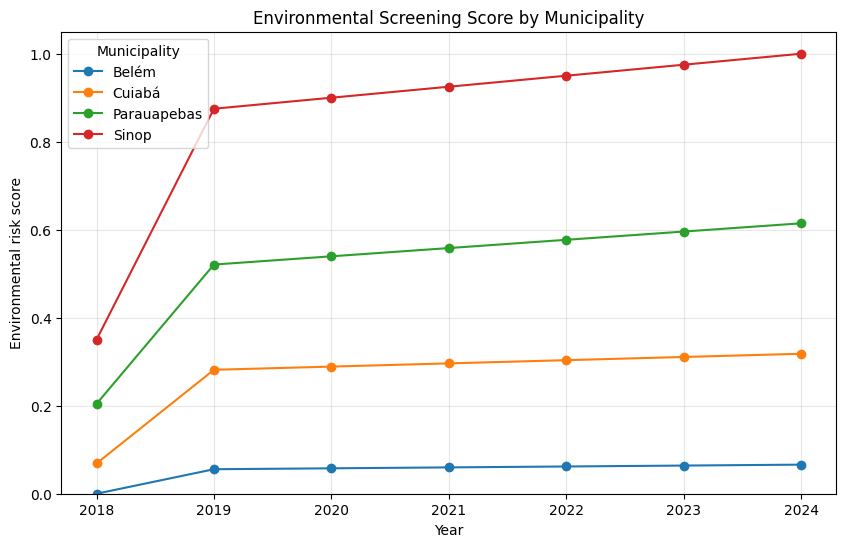

Figure saved to: C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\reports\figures\environmental_risk_score_by_municipality.png


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for municipality_name, group in scored_df.groupby("municipality_name"):
    group = group.sort_values("year")
    ax.plot(
        group["year"],
        group["environmental_risk_score"],
        marker="o",
        label=municipality_name,
    )

ax.set_title("Environmental Screening Score by Municipality")
ax.set_xlabel("Year")
ax.set_ylabel("Environmental risk score")
ax.set_ylim(0, 1.05)
ax.legend(title="Municipality")
ax.grid(True, alpha=0.3)

figure_path = FIGURES_DIR / "environmental_risk_score_by_municipality.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print("Figure saved to:", figure_path)


## 12. Create structured evidence text for RAG

The RAG system can combine:

1. retrieved document chunks;
2. structured evidence from the environmental panel.

This cell creates a simple structured evidence text block for one municipality-year.


In [13]:
def build_structured_evidence_text(row: pd.Series) -> str:
    return f"""
Municipality: {row["municipality_name"]}
State: {row["state"]}
Biome: {row["biome"]}
Year: {row["year"]}

INPE / PRODES deforestation area (ha): {row["inpe_prodes_deforestation_area_ha"]}
MapBiomas native vegetation area (ha): {row["mapbiomas_native_vegetation_area_ha"]}
MapBiomas native vegetation loss (ha): {row["mapbiomas_native_vegetation_loss_ha"]}
MapBiomas agriculture area (ha): {row["mapbiomas_agriculture_area_ha"]}
MapBiomas pasture area (ha): {row["mapbiomas_pasture_area_ha"]}
MapBiomas agriculture or pasture expansion (ha): {row["mapbiomas_agriculture_or_pasture_expansion_ha"]}

Environmental screening score: {row["environmental_risk_score"]:.3f}
Environmental screening class: {row["environmental_risk_class"]}

Important limitation:
This score is an analytical screening indicator. It is not a legal conclusion,
not proof of illegal deforestation, and not a final ESG classification.
""".strip()


selected_row = top_risk_records.merge(
    scored_df,
    on=score_columns,
    how="left",
).iloc[0]

structured_evidence_text = build_structured_evidence_text(selected_row)

print(structured_evidence_text)


Municipality: Sinop
State: MT
Biome: Amazon
Year: 2024

INPE / PRODES deforestation area (ha): 2520
MapBiomas native vegetation area (ha): 272000.0
MapBiomas native vegetation loss (ha): 8000.0
MapBiomas agriculture area (ha): 100800.0
MapBiomas pasture area (ha): 119900.0
MapBiomas agriculture or pasture expansion (ha): 3450.0

Environmental screening score: 1.000
Environmental screening class: High

Important limitation:
This score is an analytical screening indicator. It is not a legal conclusion,
not proof of illegal deforestation, and not a final ESG classification.


## 13. Optional risk summary prompt test

This cell only builds the messages that would be sent to an LLM. It does not call the model.

It checks whether the prompt template works with structured evidence.


In [14]:
from agro_rag.rag.prompts import build_risk_summary_messages

question = "Create a short environmental screening summary for this municipality-year record."

demo_context = (
    "Retrieved document evidence would appear here after querying the vector store. "
    "For this structured demo, we are focusing on the numerical panel."
)

messages = build_risk_summary_messages(
    question=question,
    structured_evidence=structured_evidence_text,
    context=demo_context,
)

for message in messages:
    print("=" * 80)
    print("ROLE:", message["role"])
    print(message["content"][:1500])
    print()


ROLE: system
# System Prompt

You are an agro-environmental document intelligence assistant.

Your role is to answer questions about Brazilian deforestation, land use, land cover, native vegetation loss, agriculture expansion and pasture expansion using only the evidence retrieved from the project knowledge base.

The project uses two source families:

1. MapBiomas
2. INPE / TerraBrasilis

You must follow these rules:

1. Use only the retrieved context.
2. Do not invent facts, numbers, sources or citations.
3. If the evidence is insufficient, say that the evidence is insufficient.
4. Always separate facts from interpretation.
5. Always mention the limitations of the answer.
6. Do not make legal conclusions.
7. Do not state that a municipality, company, farm or person committed illegal deforestation.
8. Use cautious language such as “the evidence suggests”, “the available data indicate”, or “this should be interpreted as an environmental screening signal”.
9. Prefer concise and clear an

## 14. Output files generated

This notebook generated:

```text
data/interim/cleaned_mapbiomas/mapbiomas_municipality_year.parquet
data/interim/cleaned_inpe/inpe_prodes_municipality_year.parquet
data/processed/municipality_environmental_panel.parquet
data/processed/municipality_environmental_panel_scored.parquet
reports/figures/environmental_risk_score_by_municipality.png
```

These files demonstrate the structured evidence layer of the RAG project.


In [15]:
print("Generated files:")
for path in [
    mapbiomas_path,
    inpe_path,
    environmental_panel_path,
    scored_panel_path,
    figure_path,
]:
    print("-", path, "| exists:", path.exists())


Generated files:
- C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_mapbiomas\mapbiomas_municipality_year.parquet | exists: True
- C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\interim\cleaned_inpe\inpe_prodes_municipality_year.parquet | exists: True
- C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\processed\municipality_environmental_panel.parquet | exists: True
- C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\data\processed\municipality_environmental_panel_scored.parquet | exists: True
- C:\Users\aferr\Documents\GitHub\01-rag-document-intelligence\reports\figures\environmental_risk_score_by_municipality.png | exists: True


## 15. Final interpretation

The structured layer supports the RAG system by providing numerical evidence such as:

- INPE / PRODES deforestation area;
- MapBiomas native vegetation area;
- MapBiomas native vegetation loss;
- MapBiomas agriculture area;
- MapBiomas pasture area;
- agriculture or pasture expansion;
- environmental screening score;
- environmental screening class.

The safest interpretation is:

> A higher score means that the municipality-year record deserves deeper environmental review.

It does **not** mean:

- illegal deforestation was proven;
- a municipality, company, farm or person is guilty;
- legal non-compliance was determined;
- ESG approval or rejection should be automated.
